# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit — including a machine's — is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$ — except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

In [7]:
# Part 1: your work here
import numpy as np
import astropy 

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, root_mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = np.genfromtxt('../../labs/01/data/zahisr2.csv', delimiter=',', names = True)

In [9]:
x, y, sigma_y = data['x'], data['y'], data['sigma_y']

In [10]:
# scipy.optimize curve fit for fitting linear model (as opposed to statsmodels and other methods and libraries)
# absolute_sigma = True

def line(x, m, b):
    return m * x + b
 
popt, pcov = curve_fit(line, x, y, sigma=sigma_y, absolute_sigma=True) #popt is the estimated parameters and pcov has the variances along the diagonal with parameter covariances in the other entries
m, b = popt
sigma_m, sigma_b = np.sqrt(np.diag(pcov))
initial_fit = m*x + b

R2 = r2_score(y, initial_fit)
RMSE = root_mean_squared_error(y, initial_fit)

print(f"m = {m:.4f} +- {sigma_m:.4f}")
print(f"b = {b:.4f} +- {sigma_b:.4f}")
print(f"R2 = {R2:.4f}")
print(f"RMSE = {RMSE:.4f}")

m = 2.5075 +- 0.1140
b = 17.9199 +- 0.6009
R2 = 0.6288
RMSE = 6.6468


In [11]:
# absolute_sigma = False

popt, pcov = curve_fit(line, x, y, sigma=sigma_y, absolute_sigma=False)
m2, b2 = popt
sigma_m2, sigma_b2 = np.sqrt(np.diag(pcov))

print("Model's m and b uncertainties rescaled by the Chi-Squared of the fit (sigma_y isn't treated as correct)")
print(f"m2 = {m2:.4f} +- {sigma_m2:.4f}")
print(f"b2 = {b2:.4f} +- {sigma_b2:.4f}")

Model's m and b uncertainties rescaled by the Chi-Squared of the fit (sigma_y isn't treated as correct)
m2 = 2.5075 +- 0.3621
b2 = 17.9199 +- 1.9082


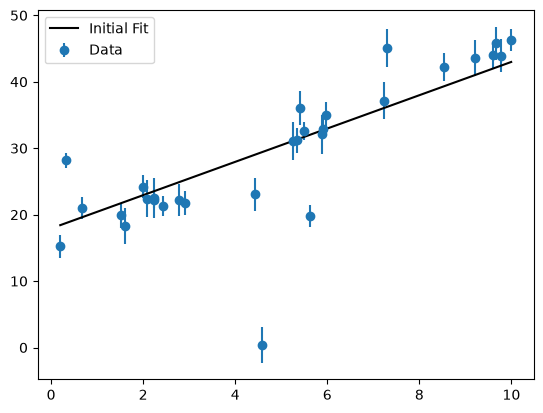

In [12]:
# plot
plt.errorbar(x, y, sigma_y, fmt='o', label='Data')
plt.plot(x, initial_fit, color = "black", label = 'Initial Fit')
plt.legend();

In [55]:
# Finding Chi-Squared
chi_sq = np.sum( (( y - initial_fit) / sigma_y)**2 )
reduced_chi_sq = chi_sq / (len(y) - 2) # the two fitted parameters are B0 and B1 (m and b)
print(f"The Reduced Chi-Squared for the initial linear model is: {reduced_chi_sq:.4f}")

The Reduced Chi-Squared for the initial linear model is: 10.0830


**ANSWER (a few sentences):**

The initial linear model has the following coefficients:
- m = **2.5075** +- **0.1140**
- b = **17.9199** +- **0.6009**

It was created using scipy.optimize's curve_fit function with the **absolute_sigma argument set to True**; this means that the data's "sigma_y" column was treated as the absolute true value for the uncertainty in y. As demonstrated above, if this was set to false, the uncertainties in the model parameters raised significantly in order to normalize to the residual variance. I believe setting this to false would lead to a similar effect to the AI output since the model is increasing its error bars to make sure the the fit of the model looks better. In the implementation I went forward with (absolute_sigma set to True), I believe the uncertainty in m and b are more accurate as they were not subject to any rescaling and were created from sigma_y.

The initial linear model has a reduced chi squared of **10.083**, signifying a poor fit to the data. When plotting, we can maybe attribute this to outliers in the data set that linear models are susceptible to.

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment — this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer** — one set of numbers
you'd put in a paper — and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

### Sigma Clipping Model

In [59]:
# Part 2: your work here
# Sigma Clipping
k = 3

mask = np.ones_like(x, dtype = bool)
for _ in range(10):
    popt, pcov = curve_fit(line, x[mask], y[mask], sigma=sigma_y[mask], absolute_sigma = True)
    m_best, b_best = popt
    sigma_m_best, sigma_b_best = np.sqrt(np.diag(pcov))
    residual = (y - (m_best*x + b_best)) / sigma_y
    new_mask = np.abs(residual) < k
    if np.array_equal(new_mask, mask):
        break
    mask = new_mask

sigma_fit = m_best*x[mask] + b_best

chi_sq_sig = np.sum( (( y[mask] - sigma_fit) / sigma_y[mask])**2 )
reduced_chi_sq_sig = chi_sq_sig / (len(y[mask]) - 2) # the two fitted parameters are B0 and B1 (m and b)
R2_sig = r2_score(y[mask], sigma_fit)
RMSE_sig = root_mean_squared_error(y[mask], sigma_fit)

print(f"The Reduced Chi-Squared for the initial linear model is: {reduced_chi_sq_sig:.4f} (with masked x and y)")
print(f"Mask Sum: {mask.sum()}") #27 means 3 are false and dropped
print(f"m: {m_best:.4f} +- {sigma_m_best:.4f}")
print(f"b: {b_best:.4f} +- {sigma_b_best:.4f}")
print(f"R2 = {R2_sig:.4f}, RMSE = {RMSE_sig:.4f}")

The Reduced Chi-Squared for the initial linear model is: 1.1199 (with masked x and y)
Mask Sum: 27
m: 3.0646 +- 0.1258
b: 15.4468 +- 0.6980
R2 = 0.9416, RMSE = 2.3633


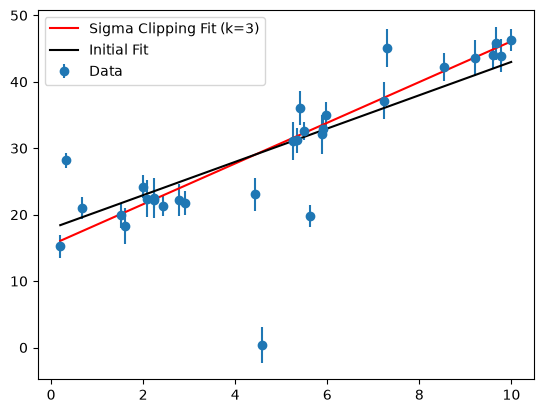

In [35]:
plt.errorbar(x, y, sigma_y, fmt='o', label='Data')
plt.plot(x[mask], sigma_fit, color = "red", label = 'Sigma Clipping Fit (k=3)')
plt.plot(x, initial_fit, color = "black", label = 'Initial Fit')
plt.legend();

### Mixture Model

In [39]:
### BELOW FROM WEEK 2 -> LECTURE 3: "The mixture-model likelihood (Hogg, Bovy & Lang 2010)"
from scipy.optimize import minimize
from scipy.stats import norm

def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sigma)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

**FINAL ANSWER:** $m = $ ___ $\pm$ ___ , $b = $ ___ $\pm$ ___ , outlier fraction $\approx$ ___

**Justification and uncertainty method (a short paragraph):**

*your answer goes here*

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong — in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:*

*Flaw 2:*

*Flaw 3:*

In [ ]:
# Part 3: demonstrations here


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

*your answer goes here*

**VERIFICATION PLAN:**

*your answer goes here*